In [61]:
import pandas as pd
import numpy as np
from collections import defaultdict

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
model_names = {
 1: 'genetics_and_image_ct_batch_cancertypebatching_exp_0_warmup_0',
 2: 'genetics_and_image_ct_batch_cancertypebatching_exp_1_warmup_10',
 3: 'genetics_and_image_all_batch_cancertypebatching_exp_0_phase2_10',
 4: 'genetics_and_image_all_batch_cancertypebatching_exp_1_phase2_0',
 5: 'only_genetics_ct_batch_cancertypebatching_exp_0_warmup_0',
 6: 'only_genetics_ct_batch_cancertypebatching_exp_1_warmup_10',
 7: 'only_genetics_all_batch_cancertypebatching_exp_0_phase2_10',
 8: 'only_genetics_all_batch_cancertypebatching_exp_1_phase2_0',
 9: 'only_image_ct_batch_cancertypebatching_exp_0_warmup_0',
 10: 'only_image_ct_batch_cancertypebatching_exp_1_warmup_10',
 11: 'only_image_all_batch_cancert  ypebatching_exp_0_phase2_10',
 12: 'only_image_all_batch_cancertypebatching_exp_1_phase2_0'}

name_models = {
    v: k for k, v in model_names.items()
}

In [85]:
name_models

{'genetics_and_image_ct_batch_cancertypebatching_exp_0_warmup_0': 1,
 'genetics_and_image_ct_batch_cancertypebatching_exp_1_warmup_10': 2,
 'genetics_and_image_all_batch_cancertypebatching_exp_0_phase2_10': 3,
 'genetics_and_image_all_batch_cancertypebatching_exp_1_phase2_0': 4,
 'only_genetics_ct_batch_cancertypebatching_exp_0_warmup_0': 5,
 'only_genetics_ct_batch_cancertypebatching_exp_1_warmup_10': 6,
 'only_genetics_all_batch_cancertypebatching_exp_0_phase2_10': 7,
 'only_genetics_all_batch_cancertypebatching_exp_1_phase2_0': 8,
 'only_image_ct_batch_cancertypebatching_exp_0_warmup_0': 9,
 'only_image_ct_batch_cancertypebatching_exp_1_warmup_10': 10,
 'only_image_all_batch_cancertypebatching_exp_0_phase2_10': 11,
 'only_image_all_batch_cancertypebatching_exp_1_phase2_0': 12}

In [ ]:
all_results = defaultdict(list)

for gen_image in ['genetics_and_image', 'only_genetics', "only_image"]:
    for batch in ['ct_batch', 'all_batch']:
        for exp in ['cancertypebatching_exp_0_warmup_0', 'cancertypebatching_exp_1_warmup_10', 'cancertypebatching_exp_0_phase2_10', 'cancertypebatching_exp_1_phase2_0']:
            path = f"/n/data2/hms/dbmi/kyu/lab/chb3333/gem-patho/models/actual_final_results/{gen_image}/{batch}/{exp}/global_test_cindices.csv"
            try:
                data = pd.read_csv(path)

                for cancer, c_idx in zip(data['cancer_type'], data['c_index']):

                    
                    all_results['gen_image'].append(gen_image)
                    all_results['batch'].append(batch)
                    all_results['exp'].append(exp)
                    all_results['cancer'].append(cancer)
                    all_results['c_index'].append(c_idx)

            except:
                pass

In [63]:
df = pd.DataFrame(all_results)

df.to_csv("./test_df.csv")

In [64]:
# Group by the required columns and compute the mean and standard error
grouped = df.groupby(['gen_image', 'batch', 'exp'])['c_index'].agg(['mean', 'sem']).reset_index()
grouped.rename(columns={'mean': 'avg_c_index', 'sem': 'se_c_index'}, inplace=True)
grouped["model"] = grouped["gen_image"] + "_" + grouped["batch"] + "_" + grouped["exp"]
grouped.to_csv("grouped.csv")
# Replot without the invalid 'errorbar' argument
grouped

,gen_image,batch,exp,avg_c_index,se_c_index,model
0,genetics_and_image,all_batch,cancertypebatching_exp_0_phase2_10,0.565273,0.009402,genetics_and_image_all_batch_cancertypebatchin...
1,genetics_and_image,all_batch,cancertypebatching_exp_1_phase2_0,0.568114,0.011121,genetics_and_image_all_batch_cancertypebatchin...
2,genetics_and_image,ct_batch,cancertypebatching_exp_0_warmup_0,0.569942,0.014200,genetics_and_image_ct_batch_cancertypebatching...
3,genetics_and_image,ct_batch,cancertypebatching_exp_1_warmup_10,0.562657,0.015320,genetics_and_image_ct_batch_cancertypebatching...
4,only_genetics,all_batch,cancertypebatching_exp_0_phase2_10,0.520306,0.012892,only_genetics_all_batch_cancertypebatching_exp...
5,only_genetics,all_batch,cancertypebatching_exp_1_phase2_0,0.529688,0.017125,only_genetics_all_batch_cancertypebatching_exp...
6,only_genetics,ct_batch,cancertypebatching_exp_0_warmup_0,0.522616,0.011641,only_genetics_ct_batch_cancertypebatching_exp_...
7,only_genetics,ct_batch,cancertypebatching_exp_1_warmup_10,0.502649,0.010776,only_genetics_ct_batch_cancertypebatching_exp_...
8,only_image,all_batch,cancertypebatching_exp_0_phase2_10,0.567504,0.009536,only_image_all_batch_cancertypebatching_exp_0_...
9,only_image,all_batch,cancertypebatching_exp_1_phase2_0,0.570331,0.009507,only_image_all_batch_cancertypebatching_exp_1_...


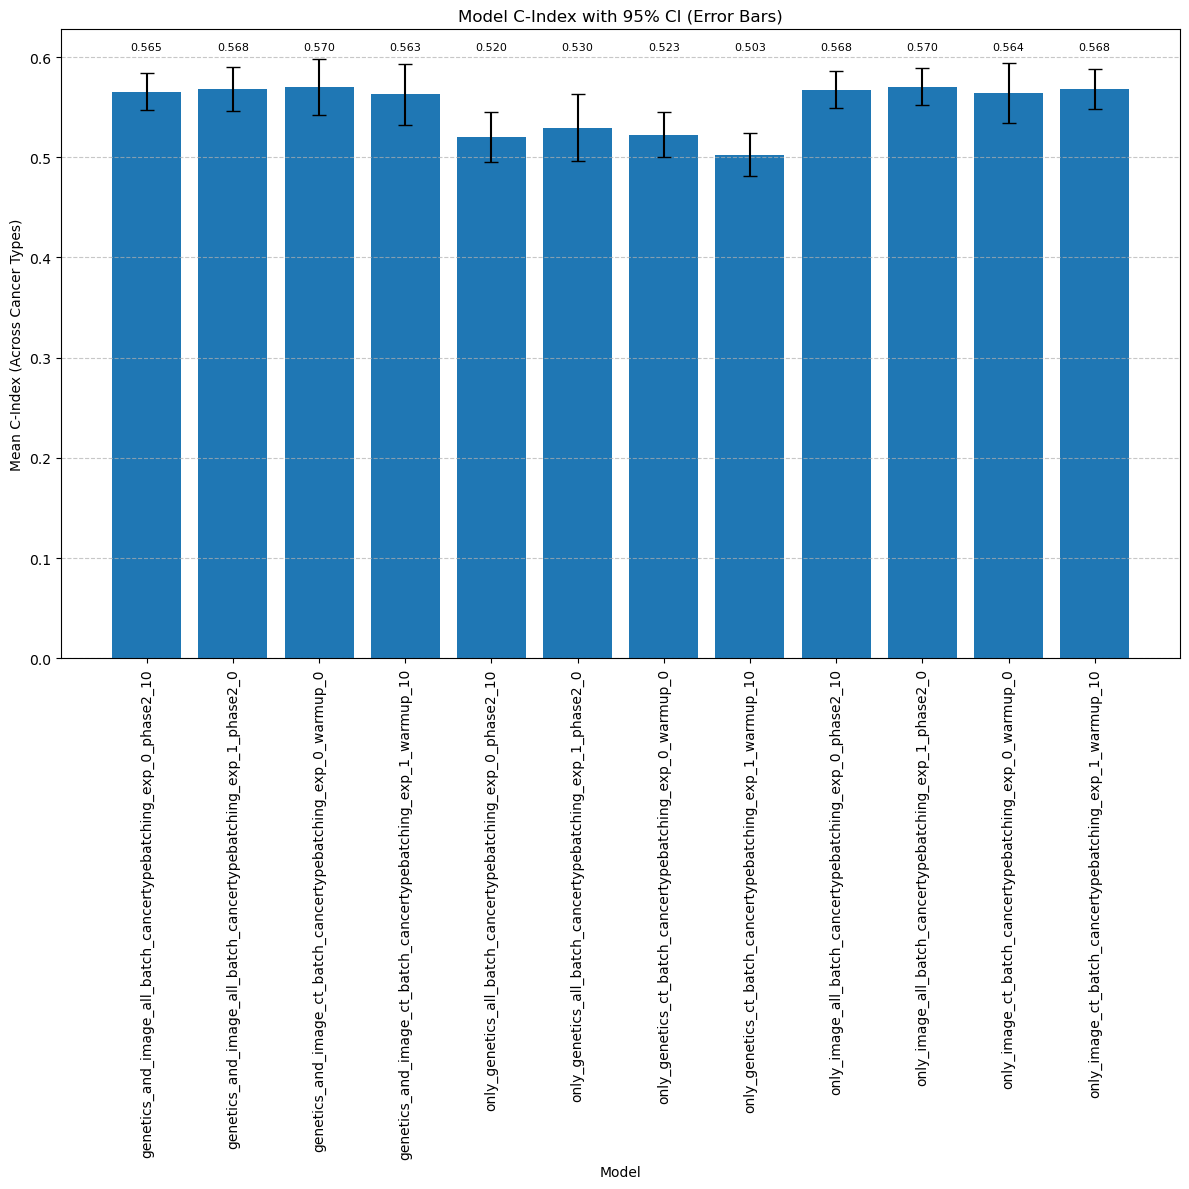

In [ ]:
df = grouped

# Calculate 95% CI = 1.96 * std_err
df["ci95"] = 1.96 * df["se_c_index"]

# Plot
plt.figure(figsize=(12, 12))
bars = plt.bar(range(len(df)), df["avg_c_index"], yerr=df["ci95"], capsize=5)
plt.xticks(range(len(df)), range(), rotation=90)
plt.ylabel("Mean C-Index (Across Cancer Types)")
plt.xlabel("Model")
plt.title("Model C-Index with 95% CI (Error Bars)")
plt.tight_layout()
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Add values above bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, 0.605, f'{height:.3f}', ha='center', va='bottom', fontsize=8)

plt.show()

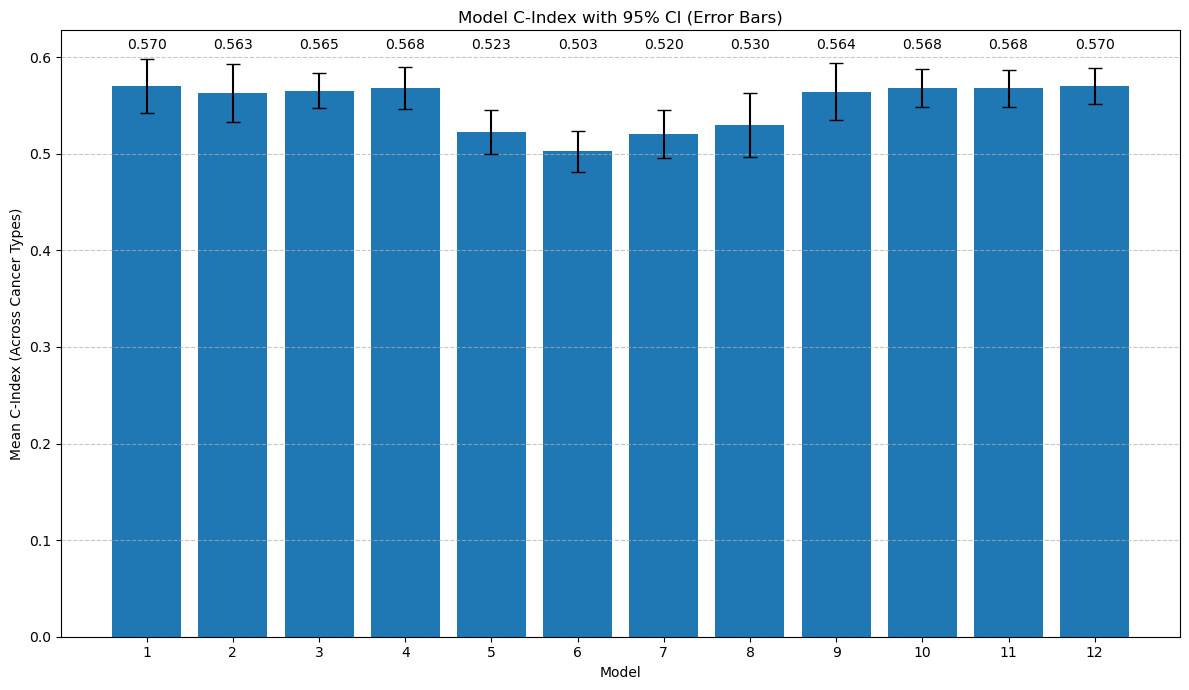

In [93]:
grouped["model_name"] = grouped["model"].map(name_models)
grouped.sort_values("model_name", inplace=True)
grouped.reset_index(drop=True, inplace=True)

df = grouped

# Calculate 95% CI = 1.96 * std_err
df["ci95"] = 1.96 * df["se_c_index"]

# Plot
plt.figure(figsize=(12, 7))
bars = plt.bar(range(len(df)), df["avg_c_index"], yerr=df["ci95"], capsize=5)
plt.xticks(range(len(df)), range(1, 13),)
plt.ylabel("Mean C-Index (Across Cancer Types)")
plt.xlabel("Model")
plt.title("Model C-Index with 95% CI (Error Bars)")
plt.tight_layout()
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Add values above bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, 0.605, f'{height:.3f}', ha='center', va='bottom', fontsize=10)

plt.show()


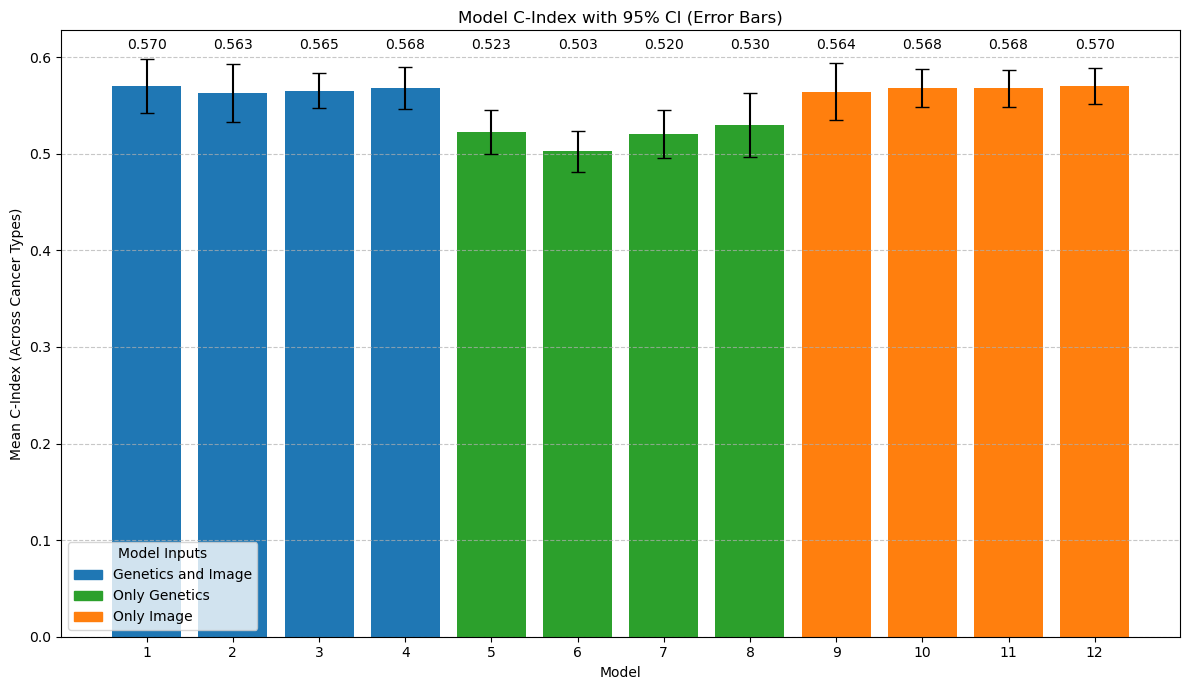

In [98]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Categorize models into groups
def get_group(name):
    if "genetics_and_image" in name:
        return "Genetics and Image"
    elif "only_genetics" in name:
        return "Only Genetics"
    elif "only_image" in name:
        return "Only Image"
    else:
        return "Other"

df["group"] = df["model"].map(get_group)

# Assign a color to each group
color_map = {
    "Genetics and Image": "tab:blue",
    "Only Genetics": "tab:green",
    "Only Image": "tab:orange",
}

colors = df["group"].map(color_map)

# Plot
plt.figure(figsize=(12, 7))
bars = plt.bar(range(len(df)), df["avg_c_index"], yerr=df["ci95"], capsize=5, color=colors)
plt.xticks(range(len(df)), range(1, len(df)+1))
plt.ylabel("Mean C-Index (Across Cancer Types)")
plt.xlabel("Model")
plt.title("Model C-Index with 95% CI (Error Bars)")
plt.tight_layout()
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Add values above bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, 0.605, f'{height:.3f}', ha='center', va='bottom', fontsize=10)

# Add legend
legend_patches = [mpatches.Patch(color=color_map[group], label=group) for group in color_map]
plt.legend(handles=legend_patches, title="Model Inputs")

plt.show()
